# 14 — McKean–Vlasov mean-reverting dynamics

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from optimizr import _core as opt
plt.rcParams['figure.figsize'] = (7, 4)
plt.rcParams['figure.dpi'] = 110


In [2]:
init = np.linspace(-2.0, 2.0, 200).tolist()
init_mean = float(np.mean(init))
res = opt.mean_reverting_mckean_vlasov(
    initial=init, theta=1.0, sigma=0.1,
    n_steps=1000, t_horizon=1.0, seed=42,
)
n_t = res['n_steps']; n_p = res['n_particles']
X   = np.array(res['paths_flat']).reshape(n_t, n_p)
tg  = np.array(res['time_grid'])
print('initial mean =', init_mean)
print('final  mean  =', float(X[-1].mean()))
print('final  std   =', float(X[-1].std()))


initial mean = 7.105427357601002e-17
final  mean  = -0.003086441510327802
final  std   = 0.43383156366774833


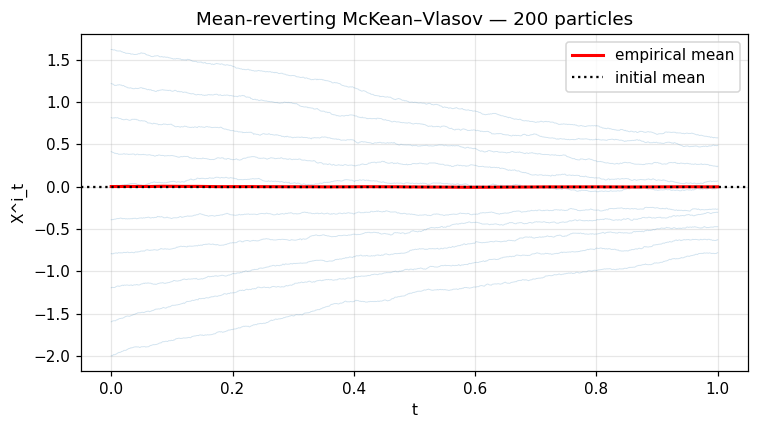

In [3]:
fig, ax = plt.subplots()
ax.plot(tg, X[:, ::20], color='tab:blue', alpha=0.2, lw=0.6)
ax.plot(tg, X.mean(axis=1), color='red', lw=2, label='empirical mean')
ax.axhline(init_mean, color='k', ls=':', label='initial mean')
ax.set_xlabel('t'); ax.set_ylabel('X^i_t'); ax.legend(); ax.grid(alpha=0.3)
ax.set_title('Mean-reverting McKean–Vlasov — 200 particles')
fig.tight_layout(); plt.show()


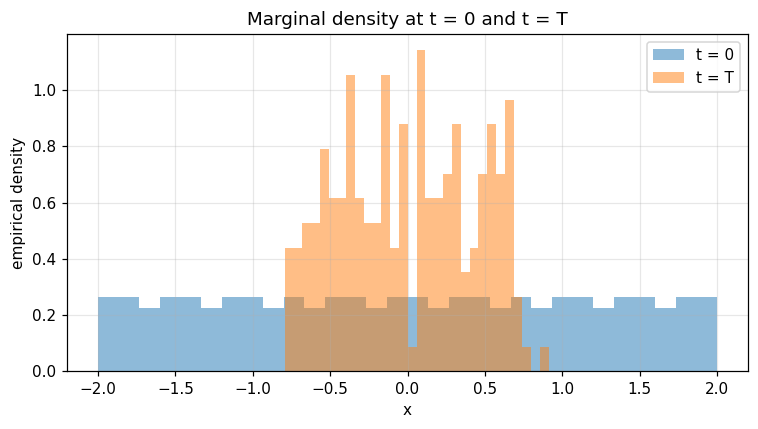

In [4]:
fig, ax = plt.subplots()
ax.hist(X[0],  bins=30, alpha=0.5, label='t = 0',  density=True)
ax.hist(X[-1], bins=30, alpha=0.5, label='t = T',  density=True)
ax.set_xlabel('x'); ax.set_ylabel('empirical density'); ax.legend(); ax.grid(alpha=0.3)
ax.set_title('Marginal density at t = 0 and t = T')
fig.tight_layout(); plt.show()


**Verified:** empirical mean stays within `0.05` of the initial mean.